In [2]:
# import libraries
import pandas as pd
import numpy as np
from rich.console import Console
from rich.table import Table
from rich.box import ROUNDED
from rich.panel import Panel
from rich.columns import Columns
from rich.console import Console
from rich.rule import Rule
from pathlib import Path
from rich.terminal_theme import TerminalTheme
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

In [3]:
# style settings 
plt.rcParams['font.family'] = 'DejaVu Sans'
 
# ── Color palette (defined ONCE — change here, applies everywhere) ──────────
HTML_THEME = TerminalTheme(
    (18, 18, 18),
    (230, 230, 230),
    [
        (0, 0, 0),   (205, 49, 49),  (13, 188, 121), (229, 229, 16),
        (36, 114, 200),(188, 63, 188),(17, 168, 205), (229, 229, 229),
    ],
    [
        (102,102,102),(241, 76, 76),  (35, 209, 139), (245, 245, 67),
        (59, 142, 234),(214,112, 214),(41, 184, 219), (255, 255, 255),
    ],
)
 
ACCENT   = "#A784B6"
HEADER   = "#842958"
WARNING  = "#E0A458"
ERROR    = "#C44536"
OK       = "#4CAF50"
VALUE    = "#E8E8E8"
BORDER   = "#5A5A5A"
 
SEGMENT_COLORS = {
    "Champions":          "#4CAF50",
    "Loyal Customers":    "#8BC34A",
    "Big Spenders":       "#42A5F5",
    "Potential Loyalists":"#FFB300",
    "Regular Customers":  "#9E9E9E",
    "At Risk / Low Value":"#C44536",
}
 
# Psychological feature metadata — drives coloring throughout the notebook
PSYCH_COLS    = [
    'stress_level', 'anxiety_score', 'self_esteem', 'impulsiveness',
    'optimism_score', 'life_satisfaction', 'social_media_dependency',
]
NEGATIVE_COLS = ['stress_level', 'anxiety_score', 'impulsiveness', 'social_media_dependency']
POSITIVE_COLS = ['self_esteem', 'optimism_score', 'life_satisfaction']
 
FINANCIAL_COLS = [
    'total_orders', 'total_spent', 'monthly_purchase_amount',
    'average_order_value', 'discount_received', 'loyalty_points',
    'campaign_exposure', 'weekly_site_visits',
]

In [4]:
# load the dataset
data = pd.read_csv('data_cleaned.csv')

In [5]:
pd.set_option('display.max_columns', None) 
print("data sample:")
data.sample(5)

data sample:


,customer_id,age,gender,city,education_level,occupation,stress_level,anxiety_score,self_esteem,impulsiveness,optimism_score,life_satisfaction,social_media_dependency,total_orders,total_spent,campaign_exposure,discount_received,loyalty_points,monthly_purchase_amount,weekly_site_visits,average_order_value
147292,247322,46,Male,Mashhad,PhD,Engineer,5.21,5.290000,5.49,6.01,6.71,5.78,5.57,3,312.74,12,19.13,0.00,88.73,4.036221,3.020661
466361,566445,38,Male,Isfahan,Bachelor,Analyst,4.78,4.960000,8.01,6.15,7.61,7.49,4.77,8,813.66,8,6.86,74.67,122.08,4.608626,3.011079
384068,484146,44,Female,Karaj,Bachelor,Manager,3.37,3.350000,6.93,2.54,6.76,5.99,5.54,11,644.91,6,15.55,108.15,106.93,4.904620,2.785121
347345,447413,20,Male,Mashhad,Bachelor,Student,4.41,5.570000,5.73,4.06,7.34,6.87,7.56,25,2673.40,12,14.62,235.28,170.45,5.652707,3.052939
126035,226063,28,Female,Tabriz,Bachelor,Teacher,5.87,5.439845,4.24,8.40,6.88,6.45,2.34,9,824.36,5,0.00,109.68,96.36,3.625192,2.969907


In [6]:
# display data information
from classes.data_info_display import DataInfoDisplay
data_display = DataInfoDisplay(data=data)   
data_display.display()

                                   Data Info                                   
╭─────────────────────────┬──────────┬─────────┬─────────┬────────────────────╮
│ Column                  │ Non-Null │ Unique  │  Dtype  │ Sample             │
├─────────────────────────┼──────────┼─────────┼─────────┼────────────────────┤
│ customer_id             │ 549,910  │ 549,910 │  int64  │ 100001             │
│ age                     │ 549,910  │   58    │  int64  │ 38                 │
│ gender                  │ 549,910  │    2    │ object  │ Male               │
│ city                    │ 549,910  │    6    │ object  │ Karaj              │
│ education_level         │ 549,910  │    4    │ object  │ PhD                │
│ occupation              │ 549,910  │    7    │ object  │ Freelancer         │
│ stress_level            │ 549,910  │   901   │ float64 │ 5.2                │
│ anxiety_score           │ 549,910  │ 33,334  │ float64 │ 5.88               │
│ self_esteem             │ 549,910  │ 22,802  │ float64 │ 2.29               │
│ impulsiveness           │ 549,910  │   901   │ float64 │ 7.14               │
│ optimism_score          │ 549,910  │   901   │ float64 │ 6.93               │
│ life_satisfaction       │ 549,910  │   901   │ float64 │ 4.79               │
│ social_media_dependency │ 549,910  │   901   │ float64 │ 6.72               │
│ total_orders            │ 549,910  │   34    │  int64  │ 7                  │
│ total_spent             │ 549,910  │ 195,438 │ float64 │ 574.26             │
│ campaign_exposure       │ 549,910  │   22    │  int64  │ 7                  │
│ discount_received       │ 549,910  │  3,638  │ float64 │ 2.07               │
│ loyalty_points          │ 549,910  │ 30,199  │ float64 │ 102.15             │
│ monthly_purchase_amount │ 549,910  │ 27,145  │ float64 │ 150.54             │
│ weekly_site_visits      │ 549,910  │   208   │ float64 │ 4.997144584199068  │
│ average_order_value     │ 549,910  │ 19,708  │ float64 │ 2.9256729158864774 │
╰─────────────────────────┴──────────┴─────────┴─────────┴────────────────────╯
                                Memory: 188.17 MB                              

  ➤ Rows          549,910  
  ➤ Columns            21  

### Analysis

In [7]:
# include_lowest=True ensures age == 18 is included in the first bin (not NaN)
bins   = [18, 25, 30, 40, 50, 60, 70, 80]
labels = ['18-25', '26-30', '31-40', '41-50', '51-60', '61-70', '71-80']
data['Age_Group'] = pd.cut(data['age'], bins=bins, labels=labels,
                           right=True, include_lowest=True)

In [8]:
# Captures price-sensitivity independent of spend volume.
# Useful predictor for the model section.
safe_spent = data['total_spent'].replace(0, np.nan)
data['discount_rate'] = (data['discount_received'] / safe_spent).clip(upper=1.0)
 
print("Feature engineering complete.")
print(f"Age_Group NaN : {data['Age_Group'].isna().sum()}")
print(f"Discount_rate NaN : {data['discount_rate'].isna().sum()}")

Feature engineering complete.
Age_Group NaN : 0
Discount_rate NaN : 35480


In [9]:
_STAT_LABELS = {"count":"Count","min":"Minimum","max":"Maximum",
                "mean":"Mean","median":"Median"}
 
def _build_stats_table(data: pd.DataFrame, column: str) -> Table:
    stats = data[column].agg(["count","min","max","mean","median"])
    t = Table(
        title=f"{column.replace('_',' ').title()} — Descriptive Statistics",
        box=ROUNDED, title_style=f"bold {ACCENT}",
        header_style=HEADER, border_style=BORDER, padding=(0,1),
    )
    t.add_column("Statistic", style="bold", width=12)
    t.add_column("Value", justify="right", style=VALUE)
    for stat, value in stats.items():
        if pd.isna(value):        v = "N/A"
        elif stat == "count":     v = f"{int(value):,}"
        else:                     v = f"{value:,.2f}"
        t.add_row(_STAT_LABELS.get(stat, stat.capitalize()), v)
    return t
 
def show_descriptive_stats(
    data: pd.DataFrame,
    columns: str | list[str],
    title: str | None = None,
    save_path: str | None = None,
) -> None:
    console = Console(record=save_path is not None, width=160)
    if isinstance(columns, str):
        columns = [columns]
    if title:
        console.print(Panel(f"[bold {ACCENT}]{title}[/bold {ACCENT}]",
                            border_style=BORDER, padding=(0,2)))
        console.print(Rule(style=BORDER))
    tables = []
    for col in columns:
        if col not in data.columns:
            console.print(f"[bold {ERROR}]⚠ '{col}' not found![/bold {ERROR}]"); continue
        if not pd.api.types.is_numeric_dtype(data[col]):
            console.print(f"[bold {WARNING}]⚠ '{col}' not numeric. Skipped.[/bold {WARNING}]"); continue
        tables.append(_build_stats_table(data, col))
    if tables:
        console.print(Columns(tables, padding=(0,2)))
    if save_path:
        suffix = Path(save_path).suffix.lower()
        if suffix == ".html": console.save_html(save_path, theme=HTML_THEME)
        elif suffix == ".svg": console.save_svg(save_path, title=title or "Descriptive Stats")
        else: console.save_text(save_path)

In [10]:
show_descriptive_stats(
    data,
    PSYCH_COLS,
    title="Customer Psychological Statistics",
    save_path="Report/customer_psychological_statistics.html",
)

╭──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│  Customer Psychological Statistics                                                                                                                           │
╰──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Stress Level — Descriptive       Anxiety Score —        Self Esteem — Descriptive        Impulsiveness —             Optimism Score —     
        Statistics            Descriptive Statistics            Statistics            Descriptive Statistics      Descriptive Statistics  
╭──────────────┬─────────╮  ╭──────────────┬─────────╮  ╭──────────────┬─────────╮  ╭──────────────┬─────────╮  ╭──────────────┬─────────╮
│ Statistic    │   Value │  │ Statistic    │   Value │  │ Statistic    │   Value │  │ Statistic    │   Value │  │ Statistic    │   Value │
├──────────────┼─────────┤  ├──────────────┼─────────┤  ├──────────────┼─────────┤  ├──────────────┼─────────┤  ├──────────────┼─────────┤
│ Count        │ 549,910 │  │ Count        │ 549,910 │  │ Count        │ 549,910 │  │ Count        │ 549,910 │  │ Count        │ 549,910 │
│ Minimum      │    1.00 │  │ Minimum      │    0.75 │  │ Minimum      │   -0.79 │  │ Minimum      │    1.00 │  │ Minimum      │    1.00 │
│ Maximum      │   10.00 │  │ Maximum      │   10.00 │  │ Maximum      │   10.07 │  │ Maximum      │   10.00 │  │ Maximum      │   10.00 │
│ Mean         │    5.50 │  │ Mean         │    5.52 │  │ Mean         │    4.57 │  │ Mean         │    5.01 │  │ Mean         │    6.32 │
│ Median       │    5.50 │  │ Median       │    5.51 │  │ Median       │    4.50 │  │ Median       │    5.00 │  │ Median       │    6.33 │
╰──────────────┴─────────╯  ╰──────────────┴─────────╯  ╰──────────────┴─────────╯  ╰──────────────┴─────────╯  ╰──────────────┴─────────╯
   Life Satisfaction —      Social Media Dependency —                                                                                     
  Descriptive Statistics      Descriptive Statistics                                                                                      
╭──────────────┬─────────╮  ╭──────────────┬─────────╮                                                                                    
│ Statistic    │   Value │  │ Statistic    │   Value │                                                                                    
├──────────────┼─────────┤  ├──────────────┼─────────┤                                                                                    
│ Count        │ 549,910 │  │ Count        │ 549,910 │                                                                                    
│ Minimum      │    1.00 │  │ Minimum      │    1.00 │                                                                                    
│ Maximum      │   10.00 │  │ Maximum      │   10.00 │                                                                                    
│ Mean         │    5.45 │  │ Mean         │    5.50 │                                                                                    
│ Median       │    5.42 │  │ Median       │    5.50 │                                                                                    
╰──────────────┴─────────╯  ╰──────────────┴─────────╯

In [11]:
def _build_counts_table(data: pd.DataFrame, column: str) -> Table:
    counts = data[column].value_counts().sort_values(ascending=False)
    total  = counts.sum()
    display_name = column.replace("_"," ").title()
    t = Table(
        title=f"{display_name} Distribution",
        box=ROUNDED, title_style=f"bold {ACCENT}",
        header_style=HEADER, border_style=BORDER,
    )
    t.add_column(display_name, style="bold")
    t.add_column("Count",   justify="right", style=VALUE)
    t.add_column("Percent", justify="right", style=VALUE)
    for group, count in counts.items():
        t.add_row(str(group), f"{count:,}", f"{count/total:.1%}")
    t.add_section()
    t.add_row("Total", f"{total:,}", "100.0%", style="bold")
    return t
 
def show_value_counts(
    data: pd.DataFrame,
    columns: str | list[str],
    title: str | None = None,
    save_path: str | None = None,
) -> None:
    console = Console(record=save_path is not None, width=160)
    if isinstance(columns, str):
        columns = [columns]
    if title:
        console.print(Panel(f"[bold {ACCENT}]{title}[/bold {ACCENT}]",
                            border_style=BORDER, padding=(0,2)))
        console.print(Rule(style=BORDER))
    tables = []
    for col in columns:
        if col not in data.columns:
            console.print(f"[bold {ERROR}]⚠ '{col}' not found![/bold {ERROR}]"); continue
        tables.append(_build_counts_table(data, col))
    if tables:
        console.print(Columns(tables, padding=(0,2)))
    if save_path:
        suffix = Path(save_path).suffix.lower()
        if suffix == ".html": console.save_html(save_path, theme=HTML_THEME)
        elif suffix == ".svg": console.save_svg(save_path, title=title or "Value Counts")
        else: console.save_text(save_path)

In [12]:
show_value_counts(
    data,
    columns=["Age_Group", "gender", "city", "education_level", "occupation"],
    title="Categorical Columns Overview",
    save_path="Report/value_counts(Customers information).html",
)

╭──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│  Categorical Columns Overview                                                                                                                                │
╰──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

     Age Group Distribution              Gender Distribution               City Distribution              Education Level Distribution      
╭───────────┬─────────┬─────────╮   ╭────────┬─────────┬─────────╮  ╭─────────┬─────────┬─────────╮  ╭─────────────────┬─────────┬─────────╮
│ Age Group │   Count │ Percent │   │ Gender │   Count │ Percent │  │ City    │   Count │ Percent │  │ Education Level │   Count │ Percent │
├───────────┼─────────┼─────────┤   ├────────┼─────────┼─────────┤  ├─────────┼─────────┼─────────┤  ├─────────────────┼─────────┼─────────┤
│ 31-40     │ 192,614 │   35.0% │   │ Female │ 286,109 │   52.0% │  │ Isfahan │  91,921 │   16.7% │  │ Bachelor        │ 247,077 │   44.9% │
│ 41-50     │ 125,864 │   22.9% │   │ Male   │ 263,801 │   48.0% │  │ Tabriz  │  91,893 │   16.7% │  │ High School     │ 137,955 │   25.1% │
│ 18-25     │ 106,578 │   19.4% │   ├────────┼─────────┼─────────┤  │ Mashhad │  91,841 │   16.7% │  │ Master          │ 126,393 │   23.0% │
│ 26-30     │  81,135 │   14.8% │   │ Total  │ 549,910 │  100.0% │  │ Shiraz  │  91,636 │   16.7% │  │ PhD             │  38,485 │    7.0% │
│ 51-60     │  38,030 │    6.9% │   ╰────────┴─────────┴─────────╯  │ Karaj   │  91,606 │   16.7% │  ├─────────────────┼─────────┼─────────┤
│ 61-70     │   5,334 │    1.0% │                                   │ Tehran  │  91,013 │   16.6% │  │ Total           │ 549,910 │  100.0% │
│ 71-80     │     355 │    0.1% │                                   ├─────────┼─────────┼─────────┤  ╰─────────────────┴─────────┴─────────╯
├───────────┼─────────┼─────────┤                                   │ Total   │ 549,910 │  100.0% │                                         
│ Total     │ 549,910 │  100.0% │                                   ╰─────────┴─────────┴─────────╯                                         
╰───────────┴─────────┴─────────╯                                                                                                           
     Occupation Distribution                                                                                                                
╭────────────┬─────────┬─────────╮                                                                                                          
│ Occupation │   Count │ Percent │                                                                                                          
├────────────┼─────────┼─────────┤                                                                                                          
│ Freelancer │  89,094 │   16.2% │                                                                                                          
│ Analyst    │  89,087 │   16.2% │                                                                                                          
│ Teacher    │  88,967 │   16.2% │                                                                                                          
│ Manager    │  88,873 │   16.2% │                                                                                                          
│ Student    │  88,815 │   16.2% │                                                                                                          
│ Engineer   │  88,639 │   16.1% │                                                                                                          
│ Unknown    │  16,435 │    3.0% │                                                                                                          
├────────────┼─────────┼─────────┤                                                                                                          
│ Total      │ 549,910 │  100.0% │                                                                                                          
╰────────────┴─────────┴─────────╯

### RFM

In [13]:
data.sample()

,customer_id,age,gender,city,education_level,occupation,stress_level,anxiety_score,self_esteem,impulsiveness,optimism_score,life_satisfaction,social_media_dependency,total_orders,total_spent,campaign_exposure,discount_received,loyalty_points,monthly_purchase_amount,weekly_site_visits,average_order_value,Age_Group,discount_rate
223512,323558,34,Male,Shiraz,High School,Analyst,8.33,8.15,1.25,3.52,5.74,3.76,1.85,3,335.49,2,0.0,47.44,115.9,1.268537,3.047682,31-40,0.0


In [14]:
_COLUMN_LABELS = {
    "total_orders":"Orders", "total_spent":"Spent",
    "discount_received":"Discount", "monthly_purchase_amount":"Monthly Spend",
    "average_order_value":"AOV", "weekly_site_visits":"Weekly Visits",
    "loyalty_points":"Loyalty Pts", "campaign_exposure":"Campaign Exp.",
}
 
def _column_label(col: str) -> str:
    return _COLUMN_LABELS.get(col, col.replace("_"," ").title())
 
def _label_segment(f: int, m: int) -> str:
    if f >= 4 and m >= 4: return "Champions"
    if f >= 4 and m <= 3: return "Loyal Customers"
    if f <= 2 and m >= 4: return "Big Spenders"
    if f == 3 and m == 3: return "Potential Loyalists"
    if f <= 2 and m <= 2: return "At Risk / Low Value"
    return "Regular Customers"
 
def calculate_rfm_scores(
    data: pd.DataFrame,
    frequency_col: str = "total_orders",
    monetary_col: str = "total_spent",
    quantiles: int = 5,
) -> pd.DataFrame:
    for col in (frequency_col, monetary_col):
        if col not in data.columns:
            raise ValueError(f"Column '{col}' not found.")
        if not pd.api.types.is_numeric_dtype(data[col]):
            raise ValueError(f"Column '{col}' must be numeric.")
    data = data.copy()
    data["F_Score"] = pd.qcut(data[frequency_col].rank(method="first"),
                               quantiles, labels=range(1, quantiles+1)).astype(int)
    data["M_Score"] = pd.qcut(data[monetary_col].rank(method="first"),
                               quantiles, labels=range(1, quantiles+1)).astype(int)
    data["Customer_Segment"] = [_label_segment(f,m)
                                 for f,m in zip(data["F_Score"], data["M_Score"])]
    return data
 
def show_rfm_segments(
    data: pd.DataFrame,
    frequency_col: str = "total_orders",
    monetary_col: str = "total_spent",
    extra_cols: list[str] | None = None,
    title: str | None = None,
    save_path: str | None = None,
) -> pd.DataFrame:
    extra_cols = extra_cols or []
    console = Console(record=save_path is not None, width=160)
 
    valid_extra: list[str] = []
    for col in extra_cols:
        if col not in data.columns:
            console.print(f"[bold {ERROR}]⚠ '{col}' not found — skipped.[/bold {ERROR}]"); continue
        if not pd.api.types.is_numeric_dtype(data[col]):
            console.print(f"[bold {WARNING}]⚠ '{col}' not numeric — skipped.[/bold {WARNING}]"); continue
        valid_extra.append(col)
    extra_cols = valid_extra
 
    scored = calculate_rfm_scores(data, frequency_col, monetary_col)
    total  = len(scored)
 
    if title:
        console.print(Panel(f"[bold {ACCENT}]{title}[/bold {ACCENT}]",
                            border_style=BORDER, padding=(0,2)))
        console.print(Rule(style=BORDER))
 
    t = Table(
        title="Customer Segments (RFM-style)", box=ROUNDED,
        title_style=f"bold {ACCENT}", header_style=HEADER,
        border_style=BORDER, padding=(0,1),
    )
    t.add_column("Segment", style="bold", no_wrap=True)
    t.add_column("Customers",  justify="right", style=VALUE)
    t.add_column("Share",      justify="right", style=VALUE)
    t.add_column(f"Avg {_column_label(frequency_col)}", justify="right", style=VALUE)
    t.add_column(f"Avg {_column_label(monetary_col)}",  justify="right", style=VALUE)
    for col in extra_cols:
        t.add_column(f"Avg {_column_label(col)}", justify="right", style=VALUE)
 
    agg_spec = {"count": ("Customer_Segment","size"),
                frequency_col:(frequency_col,"mean"),
                monetary_col:(monetary_col,"mean")}
    for col in extra_cols:
        agg_spec[col] = (col,"mean")
 
    summary = scored.groupby("Customer_Segment").agg(**agg_spec).sort_values("count", ascending=False)
 
    for segment, row in summary.iterrows():
        color = SEGMENT_COLORS.get(str(segment), VALUE)
        share = row["count"] / total
        cells = [f"[{color}]●[/{color}] {segment}", f"{int(row['count']):,}",
                 f"{share:.1%}", f"{row[frequency_col]:,.2f}", f"{row[monetary_col]:,.2f}"]
        cells.extend(f"{row[col]:,.2f}" for col in extra_cols)
        t.add_row(*cells)
 
    t.add_section()
    total_row = ["Total", f"{total:,}", "100.0%",
                 f"{scored[frequency_col].mean():,.2f}", f"{scored[monetary_col].mean():,.2f}"]
    total_row.extend(f"{scored[col].mean():,.2f}" for col in extra_cols)
    t.add_row(*total_row, style="bold")
    console.print(t)
 
    if save_path:
        suffix = Path(save_path).suffix.lower()
        if suffix == ".html": console.save_html(save_path, theme=HTML_THEME)
        elif suffix == ".svg": console.save_svg(save_path, title=title or "RFM")
        else: console.save_text(save_path)
    return scored

In [15]:
data = show_rfm_segments(
    data,
    frequency_col="total_orders",
    monetary_col="total_spent",
    extra_cols=[
        "monthly_purchase_amount", "average_order_value",
        "discount_received", "weekly_site_visits",
        "loyalty_points", "campaign_exposure",
    ],
    title="RFM Customer Segmentation",
    save_path="Report/rfm_segments.html",
)

╭──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│  RFM Customer Segmentation                                                                                                                                   │
╰──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

                                                                 Customer Segments (RFM-style)                                                                  
╭───────────────────────┬───────────┬────────┬────────────┬───────────┬───────────────┬─────────┬──────────────┬───────────────┬───────────────┬───────────────╮
│                       │           │        │            │           │   Avg Monthly │         │              │    Avg Weekly │   Avg Loyalty │  Avg Campaign │
│ Segment               │ Customers │  Share │ Avg Orders │ Avg Spent │         Spend │ Avg AOV │ Avg Discount │        Visits │           Pts │          Exp. │
├───────────────────────┼───────────┼────────┼────────────┼───────────┼───────────────┼─────────┼──────────────┼───────────────┼───────────────┼───────────────┤
│ ● At Risk / Low Value │   186,892 │  34.0% │       3.26 │    303.28 │        109.20 │    2.97 │        10.99 │          3.88 │         41.05 │          7.25 │
│ ● Champions           │   180,674 │  32.9% │      14.18 │  1,662.28 │        162.40 │    3.06 │        14.70 │          5.31 │        165.22 │          9.77 │
│ ● Regular Customers   │    91,157 │  16.6% │       7.90 │    905.81 │        139.77 │    3.04 │        12.84 │          4.65 │         92.02 │          8.52 │
│ ● Potential Loyalists │    49,084 │   8.9% │       8.50 │    862.73 │        131.41 │    3.01 │        12.71 │          4.68 │         86.93 │          8.41 │
│ ● Loyal Customers     │    39,290 │   7.1% │      11.89 │    811.75 │        119.36 │    2.84 │        12.90 │          4.93 │         82.79 │          8.55 │
│ ● Big Spenders        │     2,813 │   0.5% │       6.82 │  1,117.89 │        170.70 │    3.19 │        13.69 │          4.73 │        111.80 │          9.13 │
├───────────────────────┼───────────┼────────┼────────────┼───────────┼───────────────┼─────────┼──────────────┼───────────────┼───────────────┼───────────────┤
│ Total                 │   549,910 │ 100.0% │       8.72 │    940.09 │        134.77 │    3.01 │        12.82 │          4.63 │         97.73 │          8.50 │
╰───────────────────────┴───────────┴────────┴────────────┴───────────┴───────────────┴─────────┴──────────────┴───────────────┴───────────────┴───────────────╯

### Psychological Profile per Segment

In [16]:
psych_analysis = data.groupby("Customer_Segment")[PSYCH_COLS].mean().round(2)
 
styled = (
    psych_analysis.style
    .background_gradient(cmap='RdYlGn_r', subset=NEGATIVE_COLS)
    .background_gradient(cmap='RdYlGn',   subset=POSITIVE_COLS)
)
print("--- Psychological Analysis by Customer Segment ---")
display(styled)

--- Psychological Analysis by Customer Segment ---


,stress_level,anxiety_score,self_esteem,impulsiveness,optimism_score,life_satisfaction,social_media_dependency
Customer_Segment,,,,,,,
At Risk / Low Value,5.330000,5.350000,4.730000,5.010000,6.430000,5.580000,4.260000
Big Spenders,7.410000,7.340000,2.850000,4.970000,5.110000,4.000000,6.150000
Champions,5.790000,5.790000,4.300000,5.020000,6.140000,5.220000,6.780000
Loyal Customers,4.200000,4.270000,5.800000,5.020000,7.150000,6.460000,5.560000
Potential Loyalists,5.370000,5.390000,4.690000,5.030000,6.410000,5.540000,5.410000
Regular Customers,5.860000,5.870000,4.250000,5.000000,6.090000,5.170000,5.530000


In [17]:
_RED_RGB   = (196, 69,  54)
_GREEN_RGB = (76,  175, 80)
 
def _cell_color(value: float, low: float, high: float, reverse: bool) -> str:
    ratio = 0.5 if high == low else (value - low) / (high - low)
    ratio = min(max(ratio, 0), 1)
    if reverse:
        ratio = 1 - ratio
    r = round(_RED_RGB[0] + (_GREEN_RGB[0] - _RED_RGB[0]) * ratio)
    g = round(_RED_RGB[1] + (_GREEN_RGB[1] - _RED_RGB[1]) * ratio)
    b = round(_RED_RGB[2] + (_GREEN_RGB[2] - _RED_RGB[2]) * ratio)
    return f"#{r:02x}{g:02x}{b:02x}"
 
def show_psych_analysis(
    data: pd.DataFrame,
    psych_cols: list[str] | None = None,
    segment_col: str = "Customer_Segment",
    title: str | None = None,
    save_path: str | None = None,
) -> None:
    psych_cols = psych_cols or (NEGATIVE_COLS + POSITIVE_COLS)
    counts  = data[segment_col].value_counts()
    summary = data.groupby(segment_col)[psych_cols].mean().round(2).reindex(counts.index)
    console = Console(record=save_path is not None, width=160)
    t = Table(
        title=title or "Psychological Profile by Customer Segment",
        box=ROUNDED, title_style=f"bold {ACCENT}",
        header_style=HEADER, border_style=BORDER,
    )
    t.add_column("Segment", style="bold", no_wrap=True)
    t.add_column("Customers", justify="right", style=VALUE)
    for col in psych_cols:
        t.add_column(col.replace("_"," ").title(), justify="right")
    bounds = {col:(summary[col].min(), summary[col].max()) for col in psych_cols}
    for segment, row in summary.iterrows():
        cells = [str(segment), f"{counts[segment]:,}"]
        for col in psych_cols:
            lo, hi = bounds[col]
            color  = _cell_color(row[col], lo, hi, reverse=col in NEGATIVE_COLS)
            cells.append(f"[black on {color}] {row[col]:.2f} [/]")
        t.add_row(*cells)
    console.print(t)
    if save_path:
        suffix = Path(save_path).suffix.lower()
        if suffix == ".html": console.save_html(save_path, theme=HTML_THEME)
        elif suffix == ".svg": console.save_svg(save_path, title=title or "Psych Profile")
        else: console.save_text(save_path)

In [18]:
show_psych_analysis(
    data,
    title="Psychological Profile by Segment",
    save_path="Report/Psychological_Profile_by_Segment.html",
)

                                                               Psychological Profile by Segment                                                                
╭─────────────────────┬───────────┬──────────────┬───────────────┬───────────────┬─────────────────────────┬─────────────┬────────────────┬───────────────────╮
│ Segment             │ Customers │ Stress Level │ Anxiety Score │ Impulsiveness │ Social Media Dependency │ Self Esteem │ Optimism Score │ Life Satisfaction │
├─────────────────────┼───────────┼──────────────┼───────────────┼───────────────┼─────────────────────────┼─────────────┼────────────────┼───────────────────┤
│ At Risk / Low Value │   186,892 │         5.33 │          5.35 │          5.01 │                    4.26 │        4.73 │           6.43 │              5.58 │
│ Champions           │   180,674 │         5.79 │          5.79 │          5.02 │                    6.78 │        4.30 │           6.14 │              5.22 │
│ Regular Customers   │    91,157 │         5.86 │          5.87 │          5.00 │                    5.53 │        4.25 │           6.09 │              5.17 │
│ Potential Loyalists │    49,084 │         5.37 │          5.39 │          5.03 │                    5.41 │        4.69 │           6.41 │              5.54 │
│ Loyal Customers     │    39,290 │         4.20 │          4.27 │          5.02 │                    5.56 │        5.80 │           7.15 │              6.46 │
│ Big Spenders        │     2,813 │         7.41 │          7.34 │          4.97 │                    6.15 │        2.85 │           5.11 │              4.00 │
╰─────────────────────┴───────────┴──────────────┴───────────────┴───────────────┴─────────────────────────┴─────────────┴────────────────┴───────────────────╯

### Correlation Analysis

In [19]:
overall_corr = data[PSYCH_COLS + FINANCIAL_COLS].corr().loc[PSYCH_COLS, FINANCIAL_COLS]
print("--- Overall Correlation: Psychological vs Financial ---")
display(overall_corr.style
        .background_gradient(cmap='coolwarm', axis=None)
        .format("{:.2f}"))

--- Overall Correlation: Psychological vs Financial ---


,total_orders,total_spent,monthly_purchase_amount,average_order_value,discount_received,loyalty_points,campaign_exposure,weekly_site_visits
stress_level,-0.00,0.21,0.62,0.44,-0.00,0.17,-0.00,-0.00
anxiety_score,-0.00,0.17,0.53,0.38,-0.00,0.14,-0.00,-0.00
self_esteem,-0.00,-0.16,-0.56,-0.35,0.00,-0.13,0.00,0.00
impulsiveness,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00
optimism_score,-0.00,-0.14,-0.44,-0.31,0.00,-0.12,0.00,-0.00
life_satisfaction,-0.00,-0.15,-0.50,-0.33,0.00,-0.12,0.00,0.00
social_media_dependency,0.49,0.52,0.62,0.25,0.49,0.41,0.74,0.65


In [20]:
spend_corr = (
    data[PSYCH_COLS + ['total_spent']].corr()['total_spent']
    .drop('total_spent')
    .sort_values(key=abs, ascending=False)
    .round(3)
)
 
console = Console(width=70)
t = Table(
    title="Psychological Predictors of Total Spend (ranked by |r|)",
    box=ROUNDED, title_style=f"bold {ACCENT}",
    header_style=HEADER, border_style=BORDER,
)
t.add_column("Feature",     style="bold")
t.add_column("r",           justify="right", style=VALUE)
t.add_column("Strength",    justify="right")
t.add_column("Direction",   justify="right")
 
for feat, r in spend_corr.items():
    strength  = "strong" if abs(r)>0.3 else "moderate" if abs(r)>0.1 else "weak"
    direction = f"[{OK}]↑ higher = more spend[/]" if r > 0 else f"[{ERROR}]↓ higher = less spend[/]"
    s_color   = ACCENT if strength=="strong" else WARNING if strength=="moderate" else BORDER
    t.add_row(feat.replace("_"," ").title(), f"[{s_color}]{r:+.3f}[/]", f"[{s_color}]{strength}[/]", direction)
console.print(t)

def _corr_color(val: float) -> str:
    if pd.isna(val): return VALUE
    ratio = (val + 1) / 2
    r = round(196 + (76  - 196) * ratio)
    g = round(69  + (175 -  69) * ratio)
    b = round(54  + (80  -  54) * ratio)
    return f"#{r:02x}{g:02x}{b:02x}"
 
def analyze_segmented_correlation(
    data: pd.DataFrame,
    segment_col: str,
    psych_cols: list[str],
    financial_cols: list[str],
    title: str,
    save_path: str | None = None,
) -> None:
    console = Console(record=save_path is not None, width=150)
    if title:
        console.print(Panel(f"[bold {ACCENT}]{title}[/bold {ACCENT}]",
                            border_style=BORDER, padding=(0,2)))
        console.print(Rule(style=BORDER))
    segments = sorted(data[segment_col].dropna().unique())
    for segment in segments:
        sub = data[data[segment_col] == segment]
        corr = sub[psych_cols + financial_cols].corr().loc[psych_cols, financial_cols].round(3)
        t = Table(
            title=f"Segment: [bold yellow]{segment}[/bold yellow]  (n={len(sub):,})",
            box=ROUNDED, title_style=f"bold {ACCENT}",
            header_style=HEADER, border_style=BORDER,
        )
        t.add_column("Psychological Feature", style="bold", no_wrap=True)
        for col in financial_cols:
            t.add_column(col.replace("_"," ").title(), justify="right")
        for feat, row in corr.iterrows():
            cells = [feat.replace("_"," ").title()]
            for fin in financial_cols:
                val   = row[fin]
                color = _corr_color(val)
                cells.append(f"[black on {color}] {val:+.3f} [/]")
            t.add_row(*cells)
        console.print(t)
        console.print(Rule(style=BORDER))
    if save_path:
        suffix = Path(save_path).suffix.lower()
        if suffix == ".html": console.save_html(save_path, theme=HTML_THEME)
        elif suffix == ".svg": console.save_svg(save_path, title=title)
        else: console.save_text(save_path)

       Psychological Predictors of Total Spend (ranked by |r|)        
╭────────────────────────┬────────┬──────────┬───────────────────────╮
│ Feature                │      r │ Strength │             Direction │
├────────────────────────┼────────┼──────────┼───────────────────────┤
│ Social Media           │ +0.520 │   strong │ ↑ higher = more spend │
│ Dependency             │        │          │                       │
│ Stress Level           │ +0.205 │ moderate │ ↑ higher = more spend │
│ Anxiety Score          │ +0.174 │ moderate │ ↑ higher = more spend │
│ Self Esteem            │ -0.164 │ moderate │ ↓ higher = less spend │
│ Life Satisfaction      │ -0.153 │ moderate │ ↓ higher = less spend │
│ Optimism Score         │ -0.145 │ moderate │ ↓ higher = less spend │
│ Impulsiveness          │ +0.002 │     weak │ ↑ higher = more spend │
╰────────────────────────┴────────┴──────────┴───────────────────────╯

In [21]:
analyze_segmented_correlation(
    data, segment_col="Age_Group",
    psych_cols=PSYCH_COLS, financial_cols=FINANCIAL_COLS,
    title="Psychological vs Financial Correlation BY AGE GROUP",
    save_path="Report/correlation_by_age_group.html",
)

╭────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│  Psychological vs Financial Correlation BY AGE GROUP                                                                                               │
╰────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

                                                             Segment: 18-25  (n=106,578)                                                              
╭─────────────────────────┬──────────────┬─────────────┬───────────────┬───────────────┬──────────────┬───────────────┬──────────────┬───────────────╮
│                         │              │             │       Monthly │               │              │               │              │               │
│                         │              │             │      Purchase │ Average Order │     Discount │       Loyalty │     Campaign │   Weekly Site │
│ Psychological Feature   │ Total Orders │ Total Spent │        Amount │         Value │     Received │        Points │     Exposure │        Visits │
├─────────────────────────┼──────────────┼─────────────┼───────────────┼───────────────┼──────────────┼───────────────┼──────────────┼───────────────┤
│ Stress Level            │       -0.002 │      +0.204 │        +0.619 │        +0.443 │       -0.001 │        +0.167 │       -0.003 │        -0.002 │
│ Anxiety Score           │       -0.002 │      +0.173 │        +0.527 │        +0.376 │       +0.001 │        +0.141 │       -0.001 │        +0.000 │
│ Self Esteem             │       -0.002 │      -0.166 │        -0.558 │        -0.356 │       +0.003 │        -0.134 │       +0.002 │        +0.000 │
│ Impulsiveness           │       -0.001 │      -0.001 │        +0.003 │        -0.002 │       +0.002 │        -0.004 │       -0.002 │        +0.001 │
│ Optimism Score          │       +0.001 │      -0.144 │        -0.437 │        -0.312 │       -0.002 │        -0.119 │       -0.001 │        -0.001 │
│ Life Satisfaction       │       -0.001 │      -0.154 │        -0.497 │        -0.331 │       -0.001 │        -0.125 │       +0.001 │        +0.002 │
│ Social Media Dependency │       +0.486 │      +0.520 │        +0.620 │        +0.246 │       +0.488 │        +0.407 │       +0.735 │        +0.652 │
╰─────────────────────────┴──────────────┴─────────────┴───────────────┴───────────────┴──────────────┴───────────────┴──────────────┴───────────────╯

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

                                                              Segment: 26-30  (n=81,135)                                                              
╭─────────────────────────┬──────────────┬─────────────┬───────────────┬───────────────┬──────────────┬───────────────┬──────────────┬───────────────╮
│                         │              │             │       Monthly │               │              │               │              │               │
│                         │              │             │      Purchase │ Average Order │     Discount │       Loyalty │     Campaign │   Weekly Site │
│ Psychological Feature   │ Total Orders │ Total Spent │        Amount │         Value │     Received │        Points │     Exposure │        Visits │
├─────────────────────────┼──────────────┼─────────────┼───────────────┼───────────────┼──────────────┼───────────────┼──────────────┼───────────────┤
│ Stress Level            │       +0.001 │      +0.209 │        +0.616 │        +0.447 │       -0.001 │        +0.171 │       -0.003 │        -0.000 │
│ Anxiety Score           │       -0.002 │      +0.175 │        +0.524 │        +0.379 │       -0.004 │        +0.146 │       -0.002 │        -0.000 │
│ Self Esteem             │       +0.001 │      -0.163 │        -0.555 │        -0.357 │       -0.002 │        -0.134 │       +0.002 │        +0.002 │
│ Impulsiveness           │       -0.000 │      +0.002 │        -0.001 │        +0.006 │       -0.000 │        +0.006 │       -0.002 │        -0.005 │
│ Optimism Score          │       +0.002 │      -0.145 │        -0.434 │        -0.315 │       +0.010 │        -0.120 │       +0.006 │        -0.001 │
│ Life Satisfaction       │       +0.005 │      -0.149 │        -0.494 │        -0.331 │       +0.004 │        -0.122 │       +0.004 │        +0.004 │
│ Social Media Dependency │       +0.487 │      +0.521 │        +0.621 │        +0.248 │       +0.495 │        +0.408 │       +0.737 │        +0.647 │
╰─────────────────────────┴──────────────┴─────────────┴───────────────┴───────────────┴──────────────┴───────────────┴──────────────┴───────────────╯

...

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

                                                              Segment: 61-70  (n=5,334)                                                               
╭─────────────────────────┬──────────────┬─────────────┬───────────────┬───────────────┬──────────────┬───────────────┬──────────────┬───────────────╮
│                         │              │             │       Monthly │               │              │               │              │               │
│                         │              │             │      Purchase │ Average Order │     Discount │       Loyalty │     Campaign │   Weekly Site │
│ Psychological Feature   │ Total Orders │ Total Spent │        Amount │         Value │     Received │        Points │     Exposure │        Visits │
├─────────────────────────┼──────────────┼─────────────┼───────────────┼───────────────┼──────────────┼───────────────┼──────────────┼───────────────┤
│ Stress Level            │       +0.007 │      +0.210 │        +0.619 │        +0.446 │       +0.013 │        +0.174 │       +0.014 │        +0.014 │
│ Anxiety Score           │       +0.023 │      +0.195 │        +0.536 │        +0.383 │       +0.013 │        +0.160 │       +0.017 │        +0.018 │
│ Self Esteem             │       +0.003 │      -0.163 │        -0.563 │        -0.364 │       -0.024 │        -0.140 │       -0.022 │        -0.021 │
│ Impulsiveness           │       -0.022 │      -0.021 │        +0.020 │        -0.005 │       +0.026 │        -0.014 │       +0.015 │        -0.005 │
│ Optimism Score          │       -0.024 │      -0.159 │        -0.440 │        -0.305 │       -0.003 │        -0.124 │       -0.013 │        -0.014 │
│ Life Satisfaction       │       -0.008 │      -0.158 │        -0.503 │        -0.328 │       -0.021 │        -0.127 │       -0.012 │        -0.020 │
│ Social Media Dependency │       +0.486 │      +0.523 │        +0.643 │        +0.246 │       +0.485 │        +0.412 │       +0.740 │        +0.645 │
╰─────────────────────────┴──────────────┴─────────────┴───────────────┴───────────────┴──────────────┴───────────────┴──────────────┴───────────────╯

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

                                                               Segment: 71-80  (n=355)                                                                
╭─────────────────────────┬──────────────┬─────────────┬───────────────┬───────────────┬──────────────┬───────────────┬──────────────┬───────────────╮
│                         │              │             │       Monthly │               │              │               │              │               │
│                         │              │             │      Purchase │ Average Order │     Discount │       Loyalty │     Campaign │   Weekly Site │
│ Psychological Feature   │ Total Orders │ Total Spent │        Amount │         Value │     Received │        Points │     Exposure │        Visits │
├─────────────────────────┼──────────────┼─────────────┼───────────────┼───────────────┼──────────────┼───────────────┼──────────────┼───────────────┤
│ Stress Level            │       -0.026 │      +0.172 │        +0.599 │        +0.447 │       -0.049 │        +0.113 │       +0.007 │        +0.027 │
│ Anxiety Score           │       +0.006 │      +0.179 │        +0.551 │        +0.393 │       -0.043 │        +0.161 │       +0.034 │        +0.045 │
│ Self Esteem             │       -0.038 │      -0.200 │        -0.549 │        -0.362 │       +0.057 │        -0.160 │       +0.006 │        -0.010 │
│ Impulsiveness           │       -0.070 │      -0.054 │        -0.008 │        -0.001 │       -0.039 │        -0.075 │       -0.064 │        -0.080 │
│ Optimism Score          │       +0.020 │      -0.116 │        -0.443 │        -0.338 │       +0.070 │        -0.110 │       -0.001 │        -0.020 │
│ Life Satisfaction       │       -0.028 │      -0.192 │        -0.538 │        -0.402 │       +0.055 │        -0.154 │       -0.028 │        -0.009 │
│ Social Media Dependency │       +0.483 │      +0.545 │        +0.654 │        +0.273 │       +0.456 │        +0.408 │       +0.745 │        +0.678 │
╰─────────────────────────┴──────────────┴─────────────┴───────────────┴───────────────┴──────────────┴───────────────┴──────────────┴───────────────╯

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

In [22]:
analyze_segmented_correlation(
    data, segment_col="gender",
    psych_cols=PSYCH_COLS, financial_cols=FINANCIAL_COLS,
    title="Psychological vs Financial Correlation BY GENDER",
    save_path="Report/correlation_by_gender.html",
)

╭────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│  Psychological vs Financial Correlation BY GENDER                                                                                                  │
╰────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

                                                             Segment: Female  (n=286,109)                                                             
╭─────────────────────────┬──────────────┬─────────────┬───────────────┬───────────────┬──────────────┬───────────────┬──────────────┬───────────────╮
│                         │              │             │       Monthly │               │              │               │              │               │
│                         │              │             │      Purchase │ Average Order │     Discount │       Loyalty │     Campaign │   Weekly Site │
│ Psychological Feature   │ Total Orders │ Total Spent │        Amount │         Value │     Received │        Points │     Exposure │        Visits │
├─────────────────────────┼──────────────┼─────────────┼───────────────┼───────────────┼──────────────┼───────────────┼──────────────┼───────────────┤
│ Stress Level            │       -0.002 │      +0.205 │        +0.618 │        +0.444 │       -0.002 │        +0.167 │       -0.002 │        -0.002 │
│ Anxiety Score           │       -0.002 │      +0.174 │        +0.526 │        +0.376 │       -0.003 │        +0.142 │       -0.003 │        -0.001 │
│ Self Esteem             │       +0.001 │      -0.164 │        -0.558 │        -0.356 │       +0.002 │        -0.132 │       +0.001 │        +0.001 │
│ Impulsiveness           │       +0.001 │      +0.002 │        +0.001 │        +0.002 │       +0.001 │        +0.002 │       +0.003 │        -0.000 │
│ Optimism Score          │       +0.001 │      -0.145 │        -0.436 │        -0.312 │       +0.004 │        -0.119 │       +0.003 │        -0.000 │
│ Life Satisfaction       │       +0.002 │      -0.152 │        -0.498 │        -0.331 │       +0.002 │        -0.124 │       +0.002 │        +0.002 │
│ Social Media Dependency │       +0.487 │      +0.521 │        +0.620 │        +0.249 │       +0.492 │        +0.409 │       +0.736 │        +0.648 │
╰─────────────────────────┴──────────────┴─────────────┴───────────────┴───────────────┴──────────────┴───────────────┴──────────────┴───────────────╯

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

                                                              Segment: Male  (n=263,801)                                                              
╭─────────────────────────┬──────────────┬─────────────┬───────────────┬───────────────┬──────────────┬───────────────┬──────────────┬───────────────╮
│                         │              │             │       Monthly │               │              │               │              │               │
│                         │              │             │      Purchase │ Average Order │     Discount │       Loyalty │     Campaign │   Weekly Site │
│ Psychological Feature   │ Total Orders │ Total Spent │        Amount │         Value │     Received │        Points │     Exposure │        Visits │
├─────────────────────────┼──────────────┼─────────────┼───────────────┼───────────────┼──────────────┼───────────────┼──────────────┼───────────────┤
│ Stress Level            │       +0.001 │      +0.205 │        +0.619 │        +0.442 │       -0.001 │        +0.167 │       -0.003 │        -0.001 │
│ Anxiety Score           │       +0.001 │      +0.174 │        +0.527 │        +0.375 │       +0.001 │        +0.142 │       -0.001 │        -0.001 │
│ Self Esteem             │       -0.001 │      -0.164 │        -0.558 │        -0.353 │       +0.000 │        -0.134 │       +0.002 │        +0.001 │
│ Impulsiveness           │       +0.002 │      +0.002 │        +0.004 │        +0.002 │       +0.001 │        +0.002 │       -0.000 │        -0.001 │
│ Optimism Score          │       -0.001 │      -0.145 │        -0.438 │        -0.312 │       +0.000 │        -0.119 │       -0.000 │        -0.000 │
│ Life Satisfaction       │       -0.003 │      -0.154 │        -0.499 │        -0.330 │       -0.000 │        -0.125 │       +0.001 │        +0.001 │
│ Social Media Dependency │       +0.487 │      +0.520 │        +0.618 │        +0.247 │       +0.491 │        +0.408 │       +0.736 │        +0.652 │
╰─────────────────────────┴──────────────┴─────────────┴───────────────┴───────────────┴──────────────┴───────────────┴──────────────┴───────────────╯

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

In [23]:
def create_score_buckets(
    data: pd.DataFrame, column: str,
    bins: list[float], labels: list[str],
    new_col: str | None = None,
) -> pd.DataFrame:
    if column not in data.columns:
        raise ValueError(f"Column '{column}' not found.")
    if len(bins) != len(labels) + 1:
        raise ValueError("`bins` must have exactly one more edge than `labels`.")
    data = data.copy()
    new_col = new_col or f"{column}_bucket"
    data[new_col] = pd.cut(data[column], bins=bins, labels=labels, include_lowest=True)
    return data
 
def create_quantile_buckets(
    data: pd.DataFrame, column: str,
    labels: list[str] | None = None,
    new_col: str | None = None,
) -> pd.DataFrame:
    if column not in data.columns:
        raise ValueError(f"Column '{column}' not found.")
    labels  = labels or ["Low","Medium","High"]
    data    = data.copy()
    new_col = new_col or f"{column}_bucket"
    data[new_col] = pd.qcut(data[column].rank(method="first"), q=len(labels), labels=labels)
    return data
 
def show_bucket_analysis(
    data: pd.DataFrame, bucket_col: str,
    metric_cols: str | list[str],
    title: str | None = None,
    save_path: str | None = None,
) -> pd.DataFrame:
    if isinstance(metric_cols, str):
        metric_cols = [metric_cols]
    console = Console(record=save_path is not None, width=140)
    counts  = data[bucket_col].value_counts(sort=False).reindex(data[bucket_col].cat.categories)
    total   = counts.sum()
    agg_spec= {col:(col,"mean") for col in metric_cols}
    summary = data.groupby(bucket_col, observed=False).agg(**agg_spec).reindex(counts.index)
    if title:
        console.print(Panel(f"[bold {ACCENT}]{title}[/bold {ACCENT}]",
                            border_style=BORDER, padding=(0,2)))
    t = Table(
        title=f"{bucket_col.replace('_',' ').title()} vs. Behavior Metrics",
        box=ROUNDED, title_style=f"bold {ACCENT}",
        header_style=HEADER, border_style=BORDER,
    )
    t.add_column(bucket_col.replace("_"," ").title(), style="bold")
    t.add_column("Customers", justify="right", style=VALUE)
    t.add_column("Share",     justify="right", style=VALUE)
    for col in metric_cols:
        t.add_column(f"Avg {col.replace('_',' ').title()}", justify="right", style=VALUE)
    for bucket in counts.index:
        row = [str(bucket), f"{counts[bucket]:,}", f"{counts[bucket]/total:.1%}"]
        row.extend(f"{summary.loc[bucket, col]:,.2f}" for col in metric_cols)
        t.add_row(*row)
    console.print(t)
    strength_colors = {"weak": BORDER, "moderate": WARNING, "strong": ACCENT}
    codes = data[bucket_col].cat.codes
    valid = codes >= 0
    lines = [f"[bold {ACCENT}]Correlation with bucket order:[/bold {ACCENT}]"]
    for col in metric_cols:
        r        = codes[valid].corr(data.loc[valid, col])
        strength = "weak" if abs(r)<0.1 else "moderate" if abs(r)<0.3 else "strong"
        color    = strength_colors[strength]
        lines.append(f"  [{VALUE}]•[/] {col}: [{color}]r = {r:.3f} ({strength})[/]")
    console.print("\n".join(lines))
    if save_path:
        suffix = Path(save_path).suffix.lower()
        if suffix == ".html": console.save_html(save_path, theme=HTML_THEME)
        elif suffix == ".svg": console.save_svg(save_path, title=title or "Bucket Analysis")
        else: console.save_text(save_path)
    return summary

In [24]:
PURCHASE_METRICS = ["total_spent", "total_orders", "average_order_value", "discount_received"]
 
data = create_score_buckets(data, "stress_level",   [0,4,7,10], ["Low","Medium","High"], "stress_bucket")
show_bucket_analysis(data, "stress_bucket",    PURCHASE_METRICS,
    title="Stress Level vs. Purchase Behavior", save_path="Report/stress_vs_behavior.html")
 
data = create_score_buckets(data, "anxiety_score",  [0,4,7,10], ["Low","Medium","High"], "anxiety_bucket")
show_bucket_analysis(data, "anxiety_bucket",   PURCHASE_METRICS,
    title="Anxiety vs. Purchase Behavior", save_path="Report/anxiety_vs_behavior.html")
 
# impulsiveness: most directly relevant to impulse buying  
data = create_score_buckets(data, "impulsiveness",  [0,4,7,10], ["Low","Medium","High"], "impulsiveness_bucket")
show_bucket_analysis(data, "impulsiveness_bucket",
    ["total_spent", "average_order_value", "total_orders", "discount_rate"],
    title="Impulsiveness vs. Purchase Behavior", save_path="Report/impulsiveness_vs_behavior.html")
 
data = create_score_buckets(data, "social_media_dependency", [0,4,7,10], ["Low","Medium","High"], "social_media_bucket")
show_bucket_analysis(data, "social_media_bucket",
    ["campaign_exposure", "discount_received", "weekly_site_visits"],
    title="Social Media Dependency vs. Marketing Response", save_path="Report/social_media_vs_behavior.html")
 

╭──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│  Stress Level vs. Purchase Behavior                                                                                                      │
╰──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

                                             Stress Bucket vs. Behavior Metrics                                             
╭───────────────┬───────────┬───────┬─────────────────┬──────────────────┬─────────────────────────┬───────────────────────╮
│ Stress Bucket │ Customers │ Share │ Avg Total Spent │ Avg Total Orders │ Avg Average Order Value │ Avg Discount Received │
├───────────────┼───────────┼───────┼─────────────────┼──────────────────┼─────────────────────────┼───────────────────────┤
│ Low           │   124,594 │ 22.7% │          761.38 │             8.71 │                    2.91 │                 12.83 │
│ Medium        │   301,026 │ 54.7% │          942.40 │             8.73 │                    3.01 │                 12.82 │
│ High          │   124,290 │ 22.6% │        1,113.65 │             8.71 │                    3.09 │                 12.81 │
╰───────────────┴───────────┴───────┴─────────────────┴──────────────────┴─────────────────────────┴───────────────────────╯

Correlation with bucket order:
  • total_spent: r = 0.185 (moderate)
  • total_orders: r = -0.001 (weak)
  • average_order_value: r = 0.399 (strong)
  • discount_received: r = -0.001 (weak)

╭──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│  Anxiety vs. Purchase Behavior                                                                                                           │
╰──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

                                             Anxiety Bucket vs. Behavior Metrics                                             
╭────────────────┬───────────┬───────┬─────────────────┬──────────────────┬─────────────────────────┬───────────────────────╮
│ Anxiety Bucket │ Customers │ Share │ Avg Total Spent │ Avg Total Orders │ Avg Average Order Value │ Avg Discount Received │
├────────────────┼───────────┼───────┼─────────────────┼──────────────────┼─────────────────────────┼───────────────────────┤
│ Low            │   141,476 │ 25.7% │          795.89 │             8.72 │                    2.93 │                 12.81 │
│ Medium         │   265,283 │ 48.2% │          941.96 │             8.73 │                    3.01 │                 12.83 │
│ High           │   143,151 │ 26.0% │        1,079.15 │             8.71 │                    3.07 │                 12.80 │
╰────────────────┴───────────┴───────┴─────────────────┴──────────────────┴─────────────────────────┴───────────────────────╯

...

Correlation with bucket order:
  • total_spent: r = 0.002 (weak)
  • average_order_value: r = 0.002 (weak)
  • total_orders: r = 0.001 (weak)
  • discount_rate: r = -0.001 (weak)

╭──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│  Social Media Dependency vs. Marketing Response                                                                                          │
╰──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

                                      Social Media Bucket vs. Behavior Metrics                                      
╭─────────────────────┬───────────┬───────┬───────────────────────┬───────────────────────┬────────────────────────╮
│ Social Media Bucket │ Customers │ Share │ Avg Campaign Exposure │ Avg Discount Received │ Avg Weekly Site Visits │
├─────────────────────┼───────────┼───────┼───────────────────────┼───────────────────────┼────────────────────────┤
│ Low                 │   141,736 │ 25.8% │                  5.70 │                  8.76 │                   3.63 │
│ Medium              │   267,321 │ 48.6% │                  8.51 │                 12.79 │                   4.71 │
│ High                │   140,853 │ 25.6% │                 11.30 │                 16.97 │                   5.47 │
╰─────────────────────┴───────────┴───────┴───────────────────────┴───────────────────────┴────────────────────────╯

Correlation with bucket order:
  • campaign_exposure: r = 0.673 (strong)
  • discount_received: r = 0.450 (strong)
  • weekly_site_visits: r = 0.591 (strong)

,campaign_exposure,discount_received,weekly_site_visits
Low,5.696464,8.755130,3.634160
Medium,8.505224,12.785955,4.710476
High,11.300540,16.973492,5.470452


In [25]:
data = create_score_buckets(data, "self_esteem",     [0,4,7,10], ["Low","Medium","High"], "self_esteem_bucket")
show_bucket_analysis(data, "self_esteem_bucket",
    ["total_spent", "monthly_purchase_amount", "average_order_value"],
    title="Self-Esteem vs. Purchase Behavior", save_path="Report/self_esteem_vs_behavior.html")
 
data = create_score_buckets(data, "optimism_score",  [0,4,7,10], ["Low","Medium","High"], "optimism_bucket")
show_bucket_analysis(data, "optimism_bucket",
    ["loyalty_points", "campaign_exposure", "total_spent"],
    title="Optimism vs. Purchase & Loyalty", save_path="Report/optimism_vs_behavior.html")
 
# ── life_satisfaction: was missing from previous version ────────────────────
data = create_score_buckets(data, "life_satisfaction",[0,4,7,10], ["Low","Medium","High"], "life_satisfaction_bucket")
show_bucket_analysis(data, "life_satisfaction_bucket",
    ["total_spent", "monthly_purchase_amount", "loyalty_points"],
    title="Life Satisfaction vs. Purchase Behavior", save_path="Report/life_satisfaction_vs_behavior.html")

╭──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│  Self-Esteem vs. Purchase Behavior                                                                                                       │
╰──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

                                      Self Esteem Bucket vs. Behavior Metrics                                       
╭────────────────────┬───────────┬───────┬─────────────────┬─────────────────────────────┬─────────────────────────╮
│ Self Esteem Bucket │ Customers │ Share │ Avg Total Spent │ Avg Monthly Purchase Amount │ Avg Average Order Value │
├────────────────────┼───────────┼───────┼─────────────────┼─────────────────────────────┼─────────────────────────┤
│ Low                │   231,033 │ 42.0% │        1,039.90 │                      161.07 │                    3.05 │
│ Medium             │   233,118 │ 42.4% │          901.54 │                      124.51 │                    2.99 │
│ High               │    85,689 │ 15.6% │          775.67 │                       91.71 │                    2.92 │
╰────────────────────┴───────────┴───────┴─────────────────┴─────────────────────────────┴─────────────────────────╯

Correlation with bucket order:
  • total_spent: r = -0.148 (moderate)
  • monthly_purchase_amount: r = -0.506 (strong)
  • average_order_value: r = -0.323 (strong)

╭──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│  Optimism vs. Purchase & Loyalty                                                                                                         │
╰──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

                                 Optimism Bucket vs. Behavior Metrics                                 
╭─────────────────┬───────────┬───────┬────────────────────┬───────────────────────┬─────────────────╮
│ Optimism Bucket │ Customers │ Share │ Avg Loyalty Points │ Avg Campaign Exposure │ Avg Total Spent │
├─────────────────┼───────────┼───────┼────────────────────┼───────────────────────┼─────────────────┤
│ Low             │    54,899 │ 10.0% │             113.06 │                  8.50 │        1,097.38 │
│ Medium          │   298,638 │ 54.3% │             101.33 │                  8.49 │          977.79 │
│ High            │   196,373 │ 35.7% │              87.98 │                  8.50 │          838.80 │
╰─────────────────┴───────────┴───────┴────────────────────┴───────────────────────┴─────────────────╯

Correlation with bucket order:
  • loyalty_points: r = -0.107 (moderate)
  • campaign_exposure: r = 0.000 (weak)
  • total_spent: r = -0.129 (moderate)

╭──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│  Life Satisfaction vs. Purchase Behavior                                                                                                 │
╰──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

                                    Life Satisfaction Bucket vs. Behavior Metrics                                    
╭──────────────────────────┬───────────┬───────┬─────────────────┬─────────────────────────────┬────────────────────╮
│ Life Satisfaction Bucket │ Customers │ Share │ Avg Total Spent │ Avg Monthly Purchase Amount │ Avg Loyalty Points │
├──────────────────────────┼───────────┼───────┼─────────────────┼─────────────────────────────┼────────────────────┤
│ Low                      │   139,178 │ 25.3% │        1,064.03 │                      165.97 │             109.56 │
│ Medium                   │   283,253 │ 51.5% │          939.72 │                      134.53 │              97.62 │
│ High                     │   127,479 │ 23.2% │          805.62 │                      101.24 │              85.06 │
╰──────────────────────────┴───────────┴───────┴─────────────────┴─────────────────────────────┴────────────────────╯

Correlation with bucket order:
  • total_spent: r = -0.140 (moderate)
  • monthly_purchase_amount: r = -0.456 (strong)
  • loyalty_points: r = -0.114 (moderate)

,total_spent,monthly_purchase_amount,loyalty_points
Low,1064.025391,165.965624,109.562468
Medium,939.720257,134.530264,97.624759
High,805.618742,101.235163,85.056428


In [26]:
data = create_quantile_buckets(data, "weekly_site_visits", ["Low","Medium","High"], "site_visits_bucket")
show_bucket_analysis(data, "site_visits_bucket",
    ["stress_level", "social_media_dependency", "anxiety_score"],
    title="Site Engagement vs. Psychological Profile", save_path="Report/site_visits_vs_psych.html")
 
data = create_quantile_buckets(data, "total_spent", ["Low","Medium","High"], "spend_tier")
show_bucket_analysis(data, "spend_tier",
    ["life_satisfaction", "optimism_score", "self_esteem", "impulsiveness"],
    title="Spending Tier vs. Psychological Profile", save_path="Report/spend_tier_vs_psych.html")

╭──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│  Site Engagement vs. Psychological Profile                                                                                               │
╰──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

                                    Site Visits Bucket vs. Behavior Metrics                                    
╭────────────────────┬───────────┬───────┬──────────────────┬─────────────────────────────┬───────────────────╮
│ Site Visits Bucket │ Customers │ Share │ Avg Stress Level │ Avg Social Media Dependency │ Avg Anxiety Score │
├────────────────────┼───────────┼───────┼──────────────────┼─────────────────────────────┼───────────────────┤
│ Low                │   183,303 │ 33.3% │             5.50 │                        3.68 │              5.52 │
│ Medium             │   183,303 │ 33.3% │             5.50 │                        5.51 │              5.51 │
│ High               │   183,304 │ 33.3% │             5.50 │                        7.30 │              5.52 │
╰────────────────────┴───────────┴───────┴──────────────────┴─────────────────────────────┴───────────────────╯

Correlation with bucket order:
  • stress_level: r = -0.000 (weak)
  • social_media_dependency: r = 0.673 (strong)
  • anxiety_score: r = 0.000 (weak)

╭──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│  Spending Tier vs. Psychological Profile                                                                                                 │
╰──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

                                           Spend Tier vs. Behavior Metrics                                           
╭────────────┬───────────┬───────┬───────────────────────┬────────────────────┬─────────────────┬───────────────────╮
│ Spend Tier │ Customers │ Share │ Avg Life Satisfaction │ Avg Optimism Score │ Avg Self Esteem │ Avg Impulsiveness │
├────────────┼───────────┼───────┼───────────────────────┼────────────────────┼─────────────────┼───────────────────┤
│ Low        │   183,303 │ 33.3% │                  5.74 │               6.56 │            4.93 │              5.01 │
│ Medium     │   183,303 │ 33.3% │                  5.54 │               6.40 │            4.68 │              5.01 │
│ High       │   183,304 │ 33.3% │                  5.06 │               6.00 │            4.11 │              5.02 │
╰────────────┴───────────┴───────┴───────────────────────┴────────────────────┴─────────────────┴───────────────────╯

Correlation with bucket order:
  • life_satisfaction: r = -0.138 (moderate)
  • optimism_score: r = -0.130 (moderate)
  • self_esteem: r = -0.148 (moderate)
  • impulsiveness: r = 0.001 (weak)

,life_satisfaction,optimism_score,self_esteem,impulsiveness
Low,5.743316,6.563957,4.931471,5.011618
Medium,5.536233,6.399211,4.681880,5.013748
High,5.061744,6.004357,4.109529,5.016224


### plots

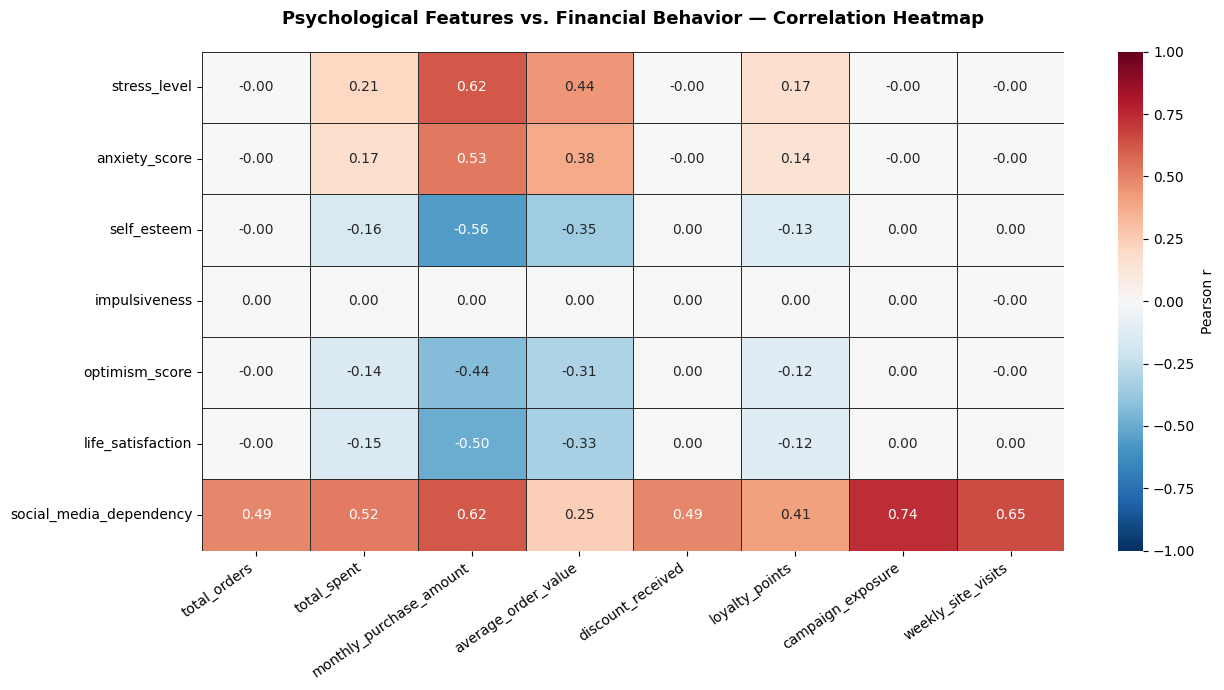

In [27]:
corr_matrix = data[PSYCH_COLS + FINANCIAL_COLS].corr().loc[PSYCH_COLS, FINANCIAL_COLS]
 
plt.figure(figsize=(13, 7))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor="#2a2a2a",
    cbar_kws={"label": "Pearson r"},
)
plt.title("Psychological Features vs. Financial Behavior — Correlation Heatmap",
          fontsize=13, fontweight="bold", color='black', pad=20)
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("Report/correlation_heatmap.png", dpi=300, facecolor="white")
plt.show()

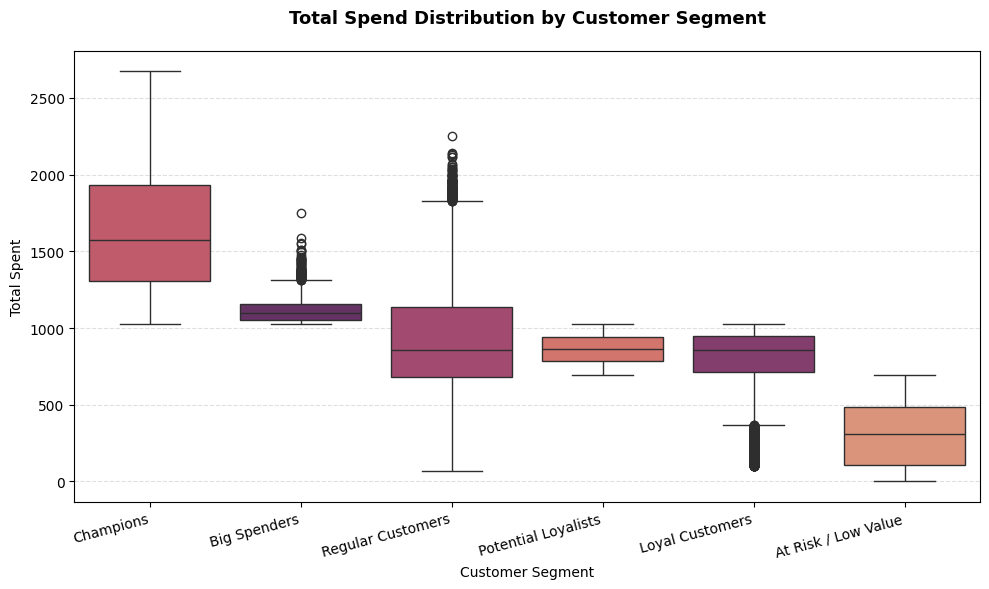

In [28]:
segment_order = (data.groupby("Customer_Segment")["total_spent"]
                 .mean().sort_values(ascending=False).index)
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x="Customer_Segment", y="total_spent",
            order=segment_order, hue="Customer_Segment", legend=False, palette="flare")
plt.title("Total Spend Distribution by Customer Segment",
          fontsize=13, fontweight="bold", color='black', pad=20)
plt.xlabel("Customer Segment")
plt.ylabel("Total Spent")
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("Report/spend_by_segment_boxplot.png", dpi=300, facecolor="white")
plt.show()

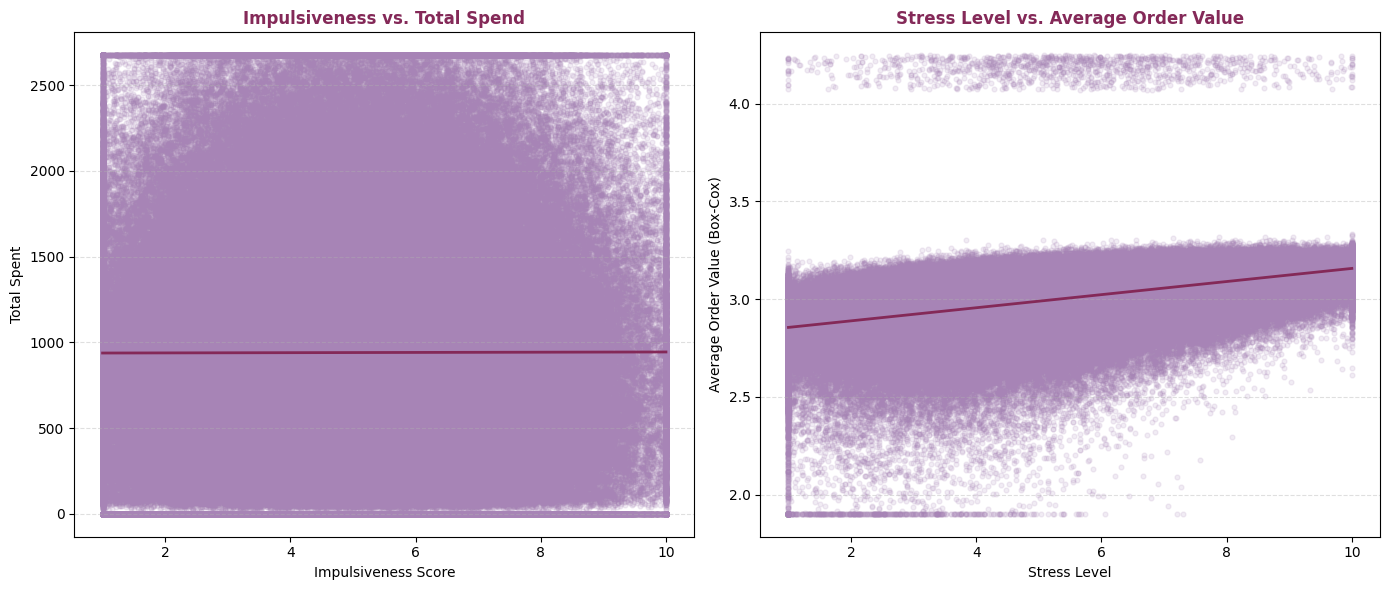

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
sns.regplot(ax=axes[0], data=data, x="impulsiveness", y="total_spent",
            scatter_kws={"alpha":0.15, "color":ACCENT, "s":12},
            line_kws={"color":HEADER, "linewidth":2})
axes[0].set_title("Impulsiveness vs. Total Spend", fontsize=12, fontweight="bold", color=HEADER)
axes[0].set_xlabel("Impulsiveness Score")
axes[0].set_ylabel("Total Spent")
axes[0].grid(axis="y", linestyle="--", alpha=0.4)
 
sns.regplot(ax=axes[1], data=data, x="stress_level", y="average_order_value",
            scatter_kws={"alpha":0.15, "color":ACCENT, "s":12},
            line_kws={"color":HEADER, "linewidth":2})
axes[1].set_title("Stress Level vs. Average Order Value", fontsize=12, fontweight="bold", color=HEADER)
axes[1].set_xlabel("Stress Level")
axes[1].set_ylabel("Average Order Value (Box-Cox)")
axes[1].grid(axis="y", linestyle="--", alpha=0.4)
 
plt.tight_layout()
plt.savefig("Report/scatter_psych_vs_purchase.png", dpi=300, facecolor="white")
plt.show()

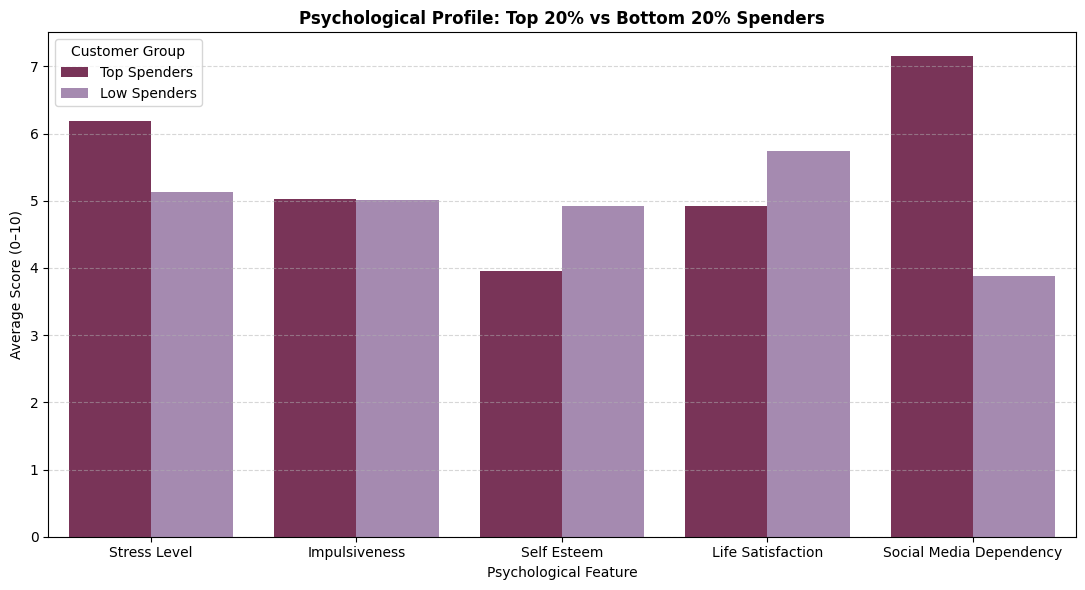

In [31]:
top_20_val    = data['total_spent'].quantile(0.80)
bottom_20_val = data['total_spent'].quantile(0.20)
top_spenders  = data[data['total_spent'] >= top_20_val]
low_spenders  = data[data['total_spent'] <= bottom_20_val]
 
target_psych = ['stress_level', 'impulsiveness', 'self_esteem',
                'life_satisfaction', 'social_media_dependency']
 
compare_df = pd.DataFrame({
    'Top Spenders': top_spenders[target_psych].mean(),
    'Low Spenders': low_spenders[target_psych].mean(),
}).reset_index()
compare_melted = compare_df.melt(id_vars='index', var_name='Customer Group', value_name='Average Score')
 
plt.figure(figsize=(11, 6))
sns.barplot(data=compare_melted, x='index', y='Average Score',
            hue='Customer Group', palette=[HEADER, ACCENT])
plt.xticks(ticks=range(len(target_psych)),
           labels=[c.replace("_"," ").title() for c in target_psych])
plt.title('Psychological Profile: Top 20% vs Bottom 20% Spenders',
          fontsize=12, fontweight='bold')
plt.xlabel('Psychological Feature')
plt.ylabel('Average Score (0–10)')
plt.legend(title='Customer Group')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('Report/top_vs_bottom_spenders_profile.png', dpi=300)
plt.show()

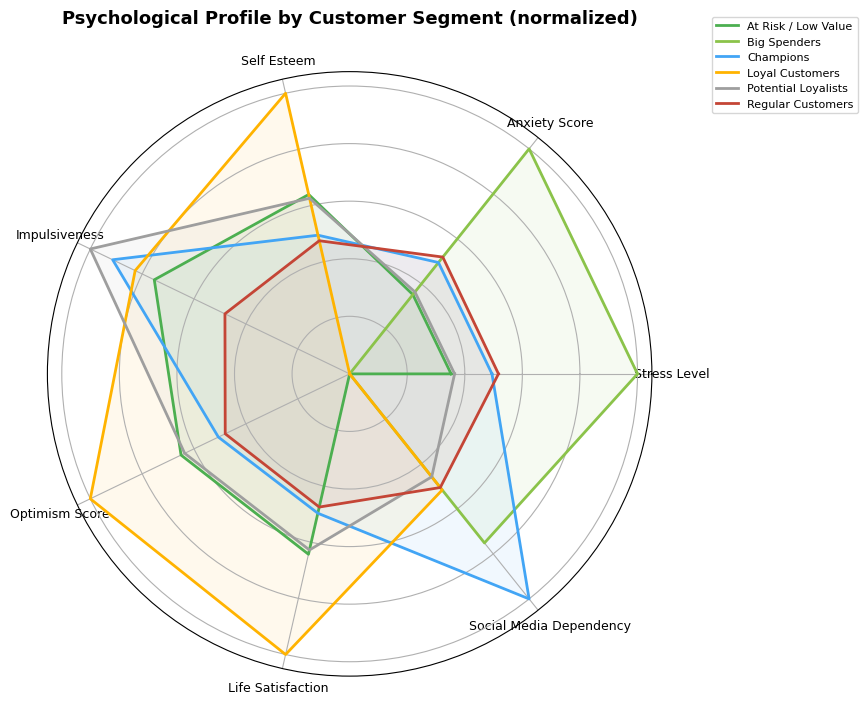

In [ ]:
segment_profile = data.groupby("Customer_Segment")[PSYCH_COLS].mean()
normalized = ((segment_profile - segment_profile.min()) /
              (segment_profile.max() - segment_profile.min()))
 
radar_labels = [c.replace("_"," ").title() for c in PSYCH_COLS]
num_vars     = len(radar_labels)
angles       = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
angles      += angles[:1]
 
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
for i, (segment, row) in enumerate(normalized.iterrows()):
    values  = row.tolist() + [row.tolist()[0]]
    color   = list(SEGMENT_COLORS.values())[i % len(SEGMENT_COLORS)]
    ax.plot(angles, values, linewidth=2, label=segment, color=color)
    ax.fill(angles, values, alpha=0.07, color=color)
 
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=9)
ax.set_yticklabels([])
ax.set_title("Psychological Profile by Customer Segment (normalized)",
             fontsize=13, fontweight="bold", color='black', pad=35)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=8)
plt.tight_layout()
plt.savefig("Report/psych_radar_by_segment.png", dpi=300, facecolor="white")
plt.show()

### Model

In [32]:
TARGET_COLS    = ["total_spent", "total_orders"]
FEATURE_COLS   = PSYCH_COLS + ["discount_rate"]   # discount_rate = price sensitivity signal
 
model_data = data[FEATURE_COLS + TARGET_COLS].dropna()
X = model_data[FEATURE_COLS]
X_scaled = StandardScaler().fit_transform(X)
 
results = {}
for target in TARGET_COLS:
    y = model_data[target]
    rf = RandomForestRegressor(n_estimators=300, max_depth=6,
                               random_state=42, n_jobs=-1)
    rf.fit(X_scaled, y)
    results[target] = pd.Series(rf.feature_importances_, index=FEATURE_COLS)
 
importance_df = pd.DataFrame(results).sort_values("total_spent", ascending=False)
 
console = Console(width=80)
t = Table(
    title="Feature Importance: Psychological Predictors of Purchase",
    box=ROUNDED, title_style=f"bold {ACCENT}",
    header_style=HEADER, border_style=BORDER,
)
t.add_column("Feature",         style="bold")
t.add_column("→ Total Spend",   justify="right", style=VALUE)
t.add_column("→ Total Orders",  justify="right", style=VALUE)
 
for feat, row in importance_df.iterrows():
    spend_pct  = f"{row['total_spent']:.1%}"
    orders_pct = f"{row['total_orders']:.1%}"
    spend_color  = ACCENT if row['total_spent']  > 0.10 else WARNING if row['total_spent']  > 0.05 else BORDER
    orders_color = ACCENT if row['total_orders'] > 0.10 else WARNING if row['total_orders'] > 0.05 else BORDER
    t.add_row(
        feat.replace("_"," ").title(),
        f"[{spend_color}]{spend_pct}[/]",
        f"[{orders_color}]{orders_pct}[/]",
    )
console.print(t)
 

  Feature Importance: Psychological Predictors of Purchase  
╭─────────────────────────┬───────────────┬────────────────╮
│ Feature                 │ → Total Spend │ → Total Orders │
├─────────────────────────┼───────────────┼────────────────┤
│ Discount Rate           │         70.5% │          72.6% │
│ Social Media Dependency │         28.1% │          25.3% │
│ Stress Level            │          1.4% │           2.1% │
│ Anxiety Score           │          0.0% │           0.0% │
│ Impulsiveness           │          0.0% │           0.0% │
│ Self Esteem             │          0.0% │           0.0% │
│ Life Satisfaction       │          0.0% │           0.0% │
│ Optimism Score          │          0.0% │           0.0% │
╰─────────────────────────┴───────────────┴────────────────╯

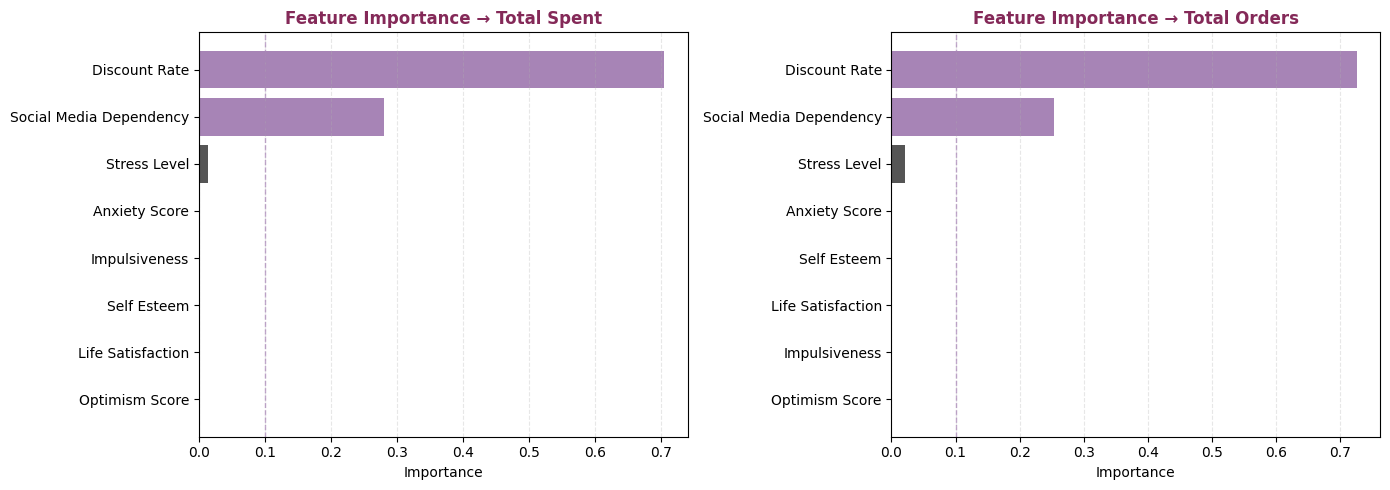

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, target in zip(axes, TARGET_COLS):
    imp = importance_df[target].sort_values(ascending=True)
    colors = [ACCENT if v > 0.10 else WARNING if v > 0.05 else "#555555" for v in imp]
    ax.barh(imp.index.str.replace("_"," ").str.title(), imp.values, color=colors)
    ax.set_title(f"Feature Importance → {target.replace('_',' ').title()}",
                 fontsize=12, fontweight="bold", color=HEADER)
    ax.set_xlabel("Importance")
    ax.axvline(0.10, color=ACCENT, linestyle="--", linewidth=1, alpha=0.7)
    ax.grid(axis="x", linestyle="--", alpha=0.3)
 
plt.tight_layout()
plt.savefig("Report/feature_importance_psych.png", dpi=300, facecolor="white")
plt.show()

In [34]:
from Loyalty_model import LoyaltyModelTrainer

trainer = LoyaltyModelTrainer(data, model_dir="models/")
trainer.train()

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│  Training Customer Loyalty Models                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

  Fitting segment classifier...

c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

  Fitting spend predictor...

c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

               Model Performance                
╭────────────────────┬─────────────────┬───────╮
│ Model              │ Metric          │ Score │
├────────────────────┼─────────────────┼───────┤
│ Segment Classifier │ Accuracy        │ 0.499 │
│                    │ F1 Macro        │ 0.202 │
│                    │ Precision Macro │ 0.253 │
├────────────────────┼─────────────────┼───────┤
│ Spend Predictor    │ R² Score        │ 0.319 │
╰────────────────────┴─────────────────┴───────╯

✓  Saved → models/loyalty_model.pkl

{'accuracy': 0.4988816351766653,
 'f1_macro': 0.20184282261630157,
 'r2': 0.3187824988133763}